# Quarter Circle with Void

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('forkserver')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, fixed_source
from ttnte.cad import Patch
from ttnte.sources import IsotropicInternalSource
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
total = 1  # 1/cm
scattering_ratio = 0.9
xs_server = Server(
    {
        "Material": {
            "total": np.array([total]),
            "scatter_gtg": np.array([[[total * scattering_ratio]]]),
        },
        "Void": {
            "total": np.array([0]),
            "scattering_gtg": np.array([0]),
        },
    }
)

In [3]:
# Create quarter circle NURBS surface
radius = 1 # cm
pitch = 2.4 # cm
c0 = cad.circle(radius=radius, angle=np.pi / 2)
c1 = c0.slice(0, 0, 0.5)
c2 = c0.slice(0, 0.5, 1)
l0 = cad.line(p0=(0, 0), p1=(0, 0))

# Create water patch
l1 = cad.line(p0=(pitch / 2, 0), p1=(pitch / 2, pitch / 2))
l2 = cad.line(p0=(pitch / 2, pitch / 2), p1=(0, pitch / 2))

# Create NURBS surfaces
fuel = [Patch(cad.ruled(l0, c1), "Material"), Patch(cad.ruled(l0, c2), "Material")]
water = [Patch(cad.ruled(c1, l1), "Void"), Patch(cad.ruled(c2, l2), "Void")]

# Add uniform source of 1/cm to patch
fuel[0].set_source(IsotropicInternalSource(np.ones((1, *fuel[0].shape))))
fuel[1].set_source(IsotropicInternalSource(np.ones((1, *fuel[1].shape))))

# Initialize IGA mesh and add the patches
mesh = IGAMesh()
for patch in fuel + water:
    mesh.add_patch(patch)

# Refine each patch to have 6 knot spans with degree 2
mesh.refine(6, 2)

# Connect patches
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=4, reflective_boundaries=True)
  -> Patch(material=Material, source=<ttnte.sources.isotropic_internal_source.IsotropicInternalSource object at 0x7f0c2cf654d0>, id=0, name=None, shape=(8, 8), backend=geomdl)
  -> Patch(material=Material, source=<ttnte.sources.isotropic_internal_source.IsotropicInternalSource object at 0x7f0a03b1f6d0>, id=1, name=None, shape=(8, 8), backend=geomdl)
  -> Patch(material=Void, source=None, id=2, name=None, shape=(8, 8), backend=geomdl)
  -> Patch(material=Void, source=None, id=3, name=None, shape=(8, 8), backend=geomdl)

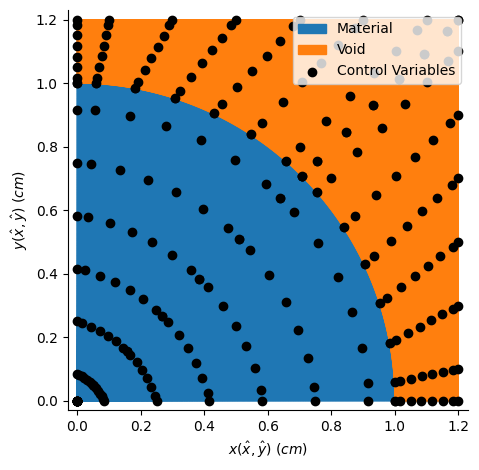

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/quarter_circle.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save TT information
assembler.save_info("./coo_info.csv")

## Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=False, eps=1e-10, q=False)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 1024, G = 1, P = 4, A = 8, B = 8
Operators: H, S, q, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 10.6 s)
Step            Ranks                     Compression
H               262144,262144                4837.72
S               1,256,256                       7.09
q               262144                          1.00
B_out           262144,262144               93565.01
B_in            262144,262144              107596.77
Running TTAssembler.build()
Discretization: N = 1024, G = 1, P = 4, A = 8, B = 8
Operators: H, S, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 98.48 s)
Step            Ranks                     Compression
H               3,3,3,10,34               2363768.46
S               1,1,1,2,18                17111423.49
B_out           4,28,41,42,8               184634.48
B_in            6,30,41,42,8               167353.78


## Solve

In [6]:
# Run fixed source calculation
psi = fixed_source(
    T=LinearOperator([tts.H, mats.B_out - mats.B_in, -tts.S], N=assembler.N, M=assembler.M),
    q=mats.q,
    device=0,
    max_iters=100,
    tol=1e-8,
    restarts=500,
)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

GMRES Finished
Elapsed Time: 99.49965190887451


<Figure size 640x480 with 0 Axes>

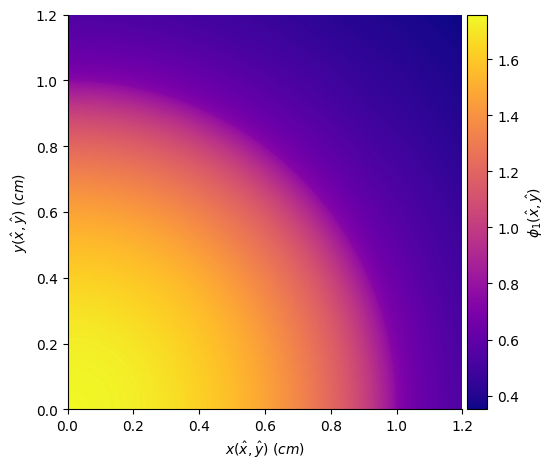

In [7]:
# Set flux
mesh.set_phi(phi[0,])

# Plot
plt.clf()
ax, cbar = mesh.plot(plot_ctrlpts=False)
cbar.set_label("$\\phi_1(\\hat{x}, \\hat{y})$")
plt.tight_layout()
plt.savefig("./figs/phi_1.png", dpi=300)
plt.show()

In [8]:
leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage / production

tensor(0.8679)